# Level 2 — is the card's "~C% chance this day will be `<predicate>`" claim calibrated?

The top card's bottom line prints **"There's a ~C% chance that this day will be
`<predicate>`"** — e.g. *"in the top 5% hottest days within ±3 days of Jun 6th"*.
C is a real CQR exceedance probability: the forecast's own 9-point calibrated band
(as a piecewise-linear predictive CDF) integrated against the climatology threshold
that the **verdict tier** picks, rounded to the nearest 5% and capped at 95%.

Level 0 (`cqr_per_level_validity`) validated the 7 trained heads; Level 1
(`cdf_rung_coverage`, NB1) validated the interpolated 9-point CDF **marginally** at
every 5% rung. This notebook closes the loop at the **product** level: it
reproduces the exact sentence the card computes for every eval-day in a 400-cell
sample and asks whether the claimed C% matches the **realized frequency** — the one
failure mode the marginal checks can't see, because it is *conditional on the tier
that actually fires* (a selection effect: "extreme" fires precisely when the
forecast median lands in the tail, where the truth regresses).

**Honest split & scope.** Bands come straight from NB1's eval-row cache
(`data/nb_confidence/eval_bands_{var}_{TAG}.feather`) — built on the held-out **eval**
month-blocks with CQR shifts fit on the disjoint **calib** blocks — so this never
touches the models. Climatology pools are the **full R2 archive** (back to 1950)
for each sampled cell, `date < target` (the target's own settled value is never in
its own pool). Gated cells (a different, already-validated empirical band path) are
excluded per variable. **One precip caveat** (plan ground-rule #7): the tier ladder
is evaluated at the cached band median, which for precip is trace-clamped, so a
sub-1 mm "drizzle" forecast ranks as dry — slightly conservative vs the live card
in arid cells; immaterial to the mild tier and reported below.

In [1]:
# --- imports, constants, and exact ports of the frontend CDF/pool primitives -----
import io, gzip, math, os, sys, time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 180, "display.float_format", lambda v: f"{v:.3f}")

TAG = "qn8620_s0_q9"
SEED = 0                                     # deterministic sample; noted per plan
N_SAMPLE = 400
WINDOW_DAYS = 3                              # CONFIG.chart.seasonalWindowDays
PRECIP_TRACE_MM = 1.0                        # confidence.ts / tieredData PRECIP_TRACE_MM
# The 9 CDF points the card integrates — all TRAINED heads as of the q9 retrain
# (q25/q75 used to be probit-interpolated in services/ci.ts).
BAND_P = np.array([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
BAND_COLS = ["q01", "lo", "q10", "q25", "mid", "q75", "q90", "hi", "q99"]
VARS = ["tmax", "tmin", "wind", "precip", "dewpt"]
ARCHIVE_COL = {"tmax": "tmax_C", "tmin": "tmin_C", "wind": "wind_max_ms",
               "precip": "precip_mm", "dewpt": "dewpt_mean_C"}
CACHE_DIR = Path("data/nb_confidence")
PULL_DIR = Path("data/archive-full-sample"); PULL_DIR.mkdir(parents=True, exist_ok=True)


def precip_trace_clamp(values):
    "confidence.ts / tieredData: a value < 1 mm reads as 0 mm (dry day)."
    values = np.asarray(values, float)
    return np.where(values < PRECIP_TRACE_MM, 0.0, values)

def value_at_tail_fraction(values, q, is_high_side):
    "confidence.ts:122 order-statistic boundary; sorts a copy, clamps the index."
    sorted_v = np.sort(np.asarray(values, float)); n = len(sorted_v)
    idx = int(np.floor((1 - q) * n)) if is_high_side else int(np.ceil(q * n)) - 1
    return float(sorted_v[min(max(idx, 0), n - 1)])

def prob_in_interval(point_v, point_p, lo, hi):
    "confidence.ts:70 — mass of the 9-point CDF in [lo,hi]; point masses + outer tails."
    v = np.asarray(point_v, float); p = np.asarray(point_p, float)
    n = len(v); total = 0.0
    if lo <= v[0]  <= hi: total += p[0]                     # mass below p01
    if lo <= v[-1] <= hi: total += 1 - p[-1]                # mass above p99
    for i in range(n - 1):
        va, vb = v[i], v[i + 1]; dp = p[i + 1] - p[i]
        if vb == va:
            if lo <= va <= hi: total += dp                  # point mass at va
        else:
            lo_c = min(max(lo, va), vb); hi_c = min(max(hi, va), vb)
            total += dp * ((hi_c - lo_c) / (vb - va))
    return float(min(max(total, 0.0), 1.0))

def js_round(x):
    "Math.round (half-up); p is non-negative so this matches the frontend rounding."
    return math.floor(x + 0.5)


# --- the frontend tier ladder (forecastReference.resolveForecastMarker, bucketed=True).
#     top5 is skipped (it is gated on !bucketed — forecast rows never reach it). ------
def resolve_forecast_marker(est_value, window_native, alltime_native):
    n = len(window_native)
    if n == 0:
        return None
    rank_high = int(np.count_nonzero(window_native >= est_value))   # dataProcessor.rankValue
    rank_low  = int(np.count_nonzero(window_native <= est_value))   # inclusive competition ranks
    is_high = rank_high <= rank_low                                 # 'auto' -> rarer side
    single_tail = (rank_high if is_high else rank_low) / n
    n_all = len(alltime_native)
    all_time_rank = 0
    if n_all > 0:
        all_time_rank = (int(np.count_nonzero(alltime_native >= est_value)) if is_high
                         else int(np.count_nonzero(alltime_native <= est_value)))
    cutoff, two_sided, uses_alltime = 0.20, False, False
    if 1 <= all_time_rank <= 10:
        tier = "alltime"; cutoff = 10 / max(1, n_all); uses_alltime = True
    elif single_tail <= 0.05:
        tier = "extreme"; cutoff = 0.05
    elif single_tail <= 0.10:                                       # bucketed unlocks mid
        tier = "mid"; cutoff = 0.10
    elif single_tail <= 0.20:
        tier = "notable"; cutoff = 0.20
    else:
        pctile = rank_low / n                                      # middle 60% -> two-sided
        tier = "mildDead" if 0.4 <= pctile <= 0.6 else "mildOff"
        cutoff = 0.20; two_sided = True
    return dict(tier=tier, is_high=is_high, single_tail=single_tail,
                all_time_rank=all_time_rank, cutoff=cutoff,
                two_sided=two_sided, uses_alltime=uses_alltime)

def claim_for_row(est_value, band_v, window_native, alltime_native):
    "TemperatureContext.tsx:407-419 — tier -> threshold value -> claimed p + displayed %."
    m = resolve_forecast_marker(est_value, window_native, alltime_native)
    if m is None:
        return None
    tier_pool = alltime_native if m["uses_alltime"] else window_native
    lo_t = value_at_tail_fraction(tier_pool, m["cutoff"], False)
    hi_t = value_at_tail_fraction(tier_pool, m["cutoff"], True)
    one_t = value_at_tail_fraction(tier_pool, m["cutoff"], m["is_high"])
    if m["two_sided"]:
        p = prob_in_interval(band_v, BAND_P, lo_t, hi_t)           # probabilityBetween
    elif m["is_high"]:
        p = prob_in_interval(band_v, BAND_P, one_t, np.inf)        # probabilityOneSided high
    else:
        p = prob_in_interval(band_v, BAND_P, -np.inf, one_t)       # probabilityOneSided low
    m.update(claimed_p=p, displayed=min(95, js_round(p * 20) * 5),
             lo_t=lo_t, hi_t=hi_t, one_t=one_t)
    return m

def outcome_hit(m, truth):
    "Did the settled value satisfy the predicate, with the SAME inclusive convention."
    if m["two_sided"]:
        return m["lo_t"] <= truth <= m["hi_t"]
    return truth >= m["one_t"] if m["is_high"] else truth <= m["one_t"]

print("primitives + tier ladder defined")

primitives + tier ladder defined


In [2]:
# --- inline port sanity: hand-built cases, assert (do not eyeball) ---------------
nd = np.array([0., 1, 2, 3, 4, 5, 6, 7, 8])                        # strictly-rising band
assert abs(prob_in_interval(nd, BAND_P, -1, 9) - 1.0) < 1e-9       # fully enclosed -> ~1
assert abs(prob_in_interval(nd, BAND_P, 4, 6) - 0.40) < 1e-9       # [mid,q90] -> .40
assert abs(prob_in_interval(nd, BAND_P, 6, np.inf) - 0.10) < 1e-9  # high tail -> .10
pool = np.random.default_rng(0).normal(size=5000)
for q in (0.05, 0.10, 0.20):
    assert abs(np.mean(pool >= value_at_tail_fraction(pool, q, True)) - q) < 1e-3
    assert abs(np.mean(pool <= value_at_tail_fraction(pool, q, False)) - q) < 1e-3
win = np.random.default_rng(1).normal(size=2000)
m_hi = resolve_forecast_marker(4.0, win, win)                      # clear high outlier
assert m_hi["is_high"] and m_hi["tier"] in ("extreme", "alltime"), m_hi
m_mid = resolve_forecast_marker(float(np.median(win)), win, win)   # dead centre
assert m_mid["two_sided"] and m_mid["tier"].startswith("mild"), m_mid
# a two-sided claim's probability is invariant to which side is 'high' (mild symmetry)
assert claim_for_row(np.median(win), nd, win, win)["two_sided"]
print("port sanity: all asserts passed")

port sanity: all asserts passed


In [3]:
# --- 1. load NB1's eval bands + build the latitude-stratified 400-cell sample ----
#     eval_bands.gated == mdt.gated_keys(TAG, 0.1) per var (baked by NB1), so we
#     exclude gated cells with the cached column and never load a model here.
eval_bands = {v: pd.read_feather(CACHE_DIR / f"eval_bands_{v}_{TAG}.feather") for v in VARS}
all_keys = eval_bands["tmax"].key.unique()
lat = pd.Series(all_keys).str.split("_").str[0].astype(float)
order = np.argsort(lat.to_numpy(), kind="stable")                  # sort by latitude
pick = np.unique(np.linspace(0, len(order) - 1, N_SAMPLE).round().astype(int))  # every k-th
sample_keys = set(all_keys[order[pick]])
print(f"sample: {len(sample_keys)} cells, latitude "
      f"{lat[order[pick]].min():.1f}..{lat[order[pick]].max():.1f}")
for v in VARS:
    ins = eval_bands[v][eval_bands[v].key.isin(sample_keys) & ~eval_bands[v].gated]
    eval_bands[v] = ins
    print(f"  {v:6s}: {len(ins):,} eval claims across {ins.key.nunique()} non-gated cells")

sample: 400 cells, latitude -54.8..78.2
  tmax  : 36,218 eval claims across 398 non-gated cells
  tmin  : 36,309 eval claims across 399 non-gated cells
  wind  : 36,400 eval claims across 400 non-gated cells
  precip: 34,489 eval claims across 379 non-gated cells
  dewpt : 36,127 eval claims across 397 non-gated cells


In [4]:
# --- 2. pull the FULL R2 archive for each sampled cell -> data/archive-full-sample/
#     (never archive-overlap/, the production input). ~400 Class B reads ~= $0.
#     Skip-if-exists; the only network step in this notebook.
def load_r2_env(path="../era5_pipeline/r2.env"):
    for line in Path(path).read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#") and "=" in line:
            k, val = line.split("=", 1); os.environ.setdefault(k, val)

def archive_key_candidates(key):
    "A prime-meridian/equator cell snaps to 0.0 but its R2 object may use -0.0."
    lat_s, lon_s = key.split("_")
    lat_opts = [lat_s] + (["-0.0"] if lat_s == "0.0" else [])
    lon_opts = [lon_s] + (["-0.0"] if lon_s == "0.0" else [])
    return [f"{la}_{lo}" for la in lat_opts for lo in lon_opts]

need = [k for k in sample_keys if not (PULL_DIR / f"archive_{k}.csv.gz").exists()]
if need:
    load_r2_env()
    sys.path.insert(0, "../era5_pipeline")
    from r2_upload import R2Uploader
    up = R2Uploader()
    def pull_one(key):
        for cand in archive_key_candidates(key):
            body = up.get_bytes(f"archive/archive_{cand}.csv.gz")
            if body is not None:
                (PULL_DIR / f"archive_{key}.csv.gz").write_bytes(body); return ("ok", key)
        return ("fail", key)
    t0 = time.time(); n_ok = n_fail = 0
    with ThreadPoolExecutor(max_workers=16) as ex:
        for fut in as_completed([ex.submit(pull_one, k) for k in need]):
            st, key = fut.result(); n_ok += st == "ok"; n_fail += st == "fail"
            if st == "fail": print("  FAIL pull", key)
    print(f"pulled {n_ok} archives ({n_fail} fail) in {(time.time()-t0)/60:.1f} min")
else:
    print(f"all {len(sample_keys)} sampled archives already local")

all 400 sampled archives already local


In [5]:
# --- 3. climatology pools + reproduce the card claim for every eval row ----------
#     Per cell: load its full archive once; per target date build the ±3-day window
#     pool and the all-time pool (both date < target); run the tier ladder + claim.
#     A truth cross-check (archive value at the target == frame truth) catches any
#     join/key bug. Cached so the analysis cells rerun without the loop.
CLAIMS_CACHE = CACHE_DIR / f"claims_reliability_{TAG}.feather"

def anchor_ord_by_year(years_unique, month, day):
    "Ordinal of (year, target month/day) — the ±window is placed per calendar year."
    ao = pd.to_datetime(dict(year=years_unique, month=month, day=day))
    return ao.values.astype("datetime64[D]").astype("int64")

def build_claims():
    records, xcheck = [], []
    t0 = time.time(); sample_list = sorted(sample_keys)
    for ci, key in enumerate(sample_list, 1):
        src = PULL_DIR / f"archive_{key}.csv.gz"
        if not src.exists():
            continue
        arch = pd.read_csv(io.BytesIO(gzip.decompress(src.read_bytes())))
        arch["date"] = pd.to_datetime(arch["date"])
        arch_ord = arch["date"].values.astype("datetime64[D]").astype("int64")
        uyears, year_idx = np.unique(arch["date"].dt.year.to_numpy(), return_inverse=True)
        vals = {v: (precip_trace_clamp(arch[ARCHIVE_COL[v]].to_numpy(float))
                    if v == "precip" else arch[ARCHIVE_COL[v]].to_numpy(float))
                for v in VARS}
        per_date = {}                                              # date -> {var: band row}
        for v in VARS:
            sub = eval_bands[v]
            for r in sub[sub.key == key].itertuples(index=False):
                per_date.setdefault(r.date, {})[v] = r
        for tdate, byvar in per_date.items():
            t_ord = np.datetime64(tdate, "D").astype("int64")
            date_lt = arch_ord < t_ord                            # strictly before target
            anchor = anchor_ord_by_year(uyears, tdate.month, tdate.day)[year_idx]
            win_mask = date_lt & (np.abs(arch_ord - anchor) <= WINDOW_DAYS)
            tgt_idx = np.where(arch_ord == t_ord)[0]              # target day, cross-check
            for v, r in byvar.items():
                band_v = np.array([getattr(r, c) for c in BAND_COLS], float)
                est = float(r.mid); truth = float(r.truth_abs)
                all_pool = vals[v][date_lt]; win_pool = vals[v][win_mask]
                if tgt_idx.size:
                    xcheck.append((v, vals[v][tgt_idx[0]] - truth))
                rec = dict(key=key, date=tdate, var=v, truth=truth, est=est,
                           n_win=len(win_pool), n_all=len(all_pool))
                if len(win_pool) >= 5:                            # frontend confidence gate
                    m = claim_for_row(est, band_v, win_pool, all_pool)
                    rec.update(tier=m["tier"], is_high=m["is_high"],
                               single_tail=m["single_tail"], uses_alltime=m["uses_alltime"],
                               claimed_p=m["claimed_p"], displayed=m["displayed"],
                               hit=int(outcome_hit(m, truth)))
                else:
                    rec.update(tier=None, claimed_p=np.nan, displayed=np.nan, hit=np.nan)
                records.append(rec)
        if ci % 100 == 0:
            print(f"  [{ci}/{len(sample_list)}] {len(records):,} claims  "
                  f"{(time.time()-t0)/60:.1f} min")
    return pd.DataFrame(records), pd.DataFrame(xcheck, columns=["var", "diff"])

if CLAIMS_CACHE.exists():
    claims = pd.read_feather(CLAIMS_CACHE); xcheck_df = None
    print(f"loaded cached claims ({len(claims):,}) from {CLAIMS_CACHE.name}")
else:
    claims, xcheck_df = build_claims()
    claims.to_feather(CLAIMS_CACHE)
    print(f"built {len(claims):,} claims -> {CLAIMS_CACHE.name}")

print("with-confidence rows (window pool n>=5):", int(claims.claimed_p.notna().sum()),
      "of", len(claims))

# truth cross-check — the archive value at each target must equal the frame's truth
if xcheck_df is not None:
    print("\ntruth cross-check |archive(target) - frame truth|:")
    worst = 0.0
    for v in VARS:
        d = xcheck_df[xcheck_df["var"] == v]["diff"].abs()
        worst = max(worst, d.max())
        print(f"  {v:6s}: n={len(d):,}  max={d.max():.4f}  p99={d.quantile(.99):.4f}")
    assert worst < 0.05, f"archive<->frame truth mismatch {worst:.3f} — join/version bug"
    print(f"  OK (worst {worst:.4f} mm/deg/ms — pools are consistent with the labels)")

  [100/400] 45,227 claims  0.7 min


  [200/400] 89,544 claims  1.4 min


  [300/400] 134,407 claims  2.2 min


  [400/400] 179,543 claims  2.9 min


built 179,543 claims -> claims_reliability_qn8620_s0_q9.feather
with-confidence rows (window pool n>=5): 179543 of 179543

truth cross-check |archive(target) - frame truth|:
  tmax  : n=36,218  max=0.0000  p99=0.0000
  tmin  : n=36,309  max=0.0000  p99=0.0000
  wind  : n=36,400  max=0.0000  p99=0.0000
  precip: n=34,489  max=0.0000  p99=0.0000
  dewpt : n=36,127  max=0.0000  p99=0.0000
  OK (worst 0.0000 mm/deg/ms — pools are consistent with the labels)


In [6]:
# --- reliability helpers --------------------------------------------------------
def wilson(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    ph = k / n; den = 1 + z*z/n
    c = (ph + z*z/(2*n)) / den
    h = z*np.sqrt(ph*(1-ph)/n + z*z/(4*n*n)) / den
    return c - h, c + h

def reliability_table(df, by="claimed_p"):
    "5-pp bins of the claimed p (or displayed %) vs realized frequency, with Wilson CI."
    edges = np.arange(0, 1.0001, 0.05)
    df = df[df.claimed_p.notna()].copy()
    key = df.claimed_p if by == "claimed_p" else df.displayed / 100
    recs = []
    for b, g in df.groupby(pd.cut(key, edges, include_lowest=True), observed=True):
        n = len(g); k = int(g.hit.sum()); lo, hi = wilson(k, n)
        mc = (g.claimed_p.mean() if by == "claimed_p" else g.displayed.mean() / 100)
        recs.append(dict(bin=str(b), n=n, mean_claim=round(mc*100, 1),
                         realized=round(k/n*100, 1), lo=round(lo*100, 1),
                         hi=round(hi*100, 1), gap=round((k/n - mc)*100, 1),
                         diag_in=bool(lo <= mc <= hi)))
    return pd.DataFrame(recs)

def ece(df):
    "Claim-weighted expected calibration error, percentage points."
    df = df[df.claimed_p.notna()]; N = len(df); tot = 0.0
    edges = np.arange(0, 1.0001, 0.05)
    for b, g in df.groupby(pd.cut(df.claimed_p, edges, include_lowest=True), observed=True):
        if len(g):
            tot += len(g)/N * abs(g.hit.mean() - g.claimed_p.mean())
    return tot * 100

TIER_ORDER = ["alltime", "extreme", "mid", "notable", "mildOff", "mildDead"]
def tier_table(df):
    "Per-tier reliability — the selection view the marginal bins can't show."
    df = df[df.claimed_p.notna()]; recs = []
    for t in TIER_ORDER:
        g = df[df.tier == t]
        if not len(g):
            continue
        k, n = int(g.hit.sum()), len(g); lo, hi = wilson(k, n)
        recs.append(dict(tier=t, n=n, claim=round(g.claimed_p.mean()*100, 1),
                         realized=round(k/n*100, 1), ci_lo=round(lo*100, 1),
                         ci_hi=round(hi*100, 1), gap=round((k/n - g.claimed_p.mean())*100, 1)))
    return pd.DataFrame(recs)
print("reliability helpers defined")

reliability helpers defined


In [7]:
# --- per-var reliability by claimed p, and by tier ------------------------------
ece_by_var = {v: ece(claims[claims["var"] == v]) for v in VARS}
for v in VARS:
    df = claims[claims["var"] == v]
    print(f"\n===== {v}: reliability by claimed p   (ECE = {ece_by_var[v]:.2f} pp) =====")
    print(reliability_table(df).to_string(index=False))
    print("  per-tier (the selection view):")
    print(tier_table(df).to_string(index=False))


===== tmax: reliability by claimed p   (ECE = 1.19 pp) =====
        bin    n  mean_claim  realized     lo     hi    gap  diag_in
(0.35, 0.4]   23      38.600    56.500 36.800 74.400 17.900     True
(0.4, 0.45]  120      43.100    50.000 41.200 58.800  6.900     True
(0.45, 0.5]  598      48.000    57.200 53.200 61.100  9.200    False
(0.5, 0.55] 3876      52.500    50.400 48.800 51.900 -2.200    False
(0.55, 0.6] 3665      57.500    56.700 55.100 58.300 -0.800     True
(0.6, 0.65] 3524      62.400    61.800 60.200 63.400 -0.700     True
(0.65, 0.7] 3126      67.500    67.200 65.500 68.800 -0.300     True
(0.7, 0.75] 2855      72.400    72.700 71.000 74.300  0.200     True
(0.75, 0.8] 3530      77.400    75.600 74.100 77.000 -1.800    False
(0.8, 0.85] 2819      82.400    81.600 80.200 83.000 -0.800     True
(0.85, 0.9] 2452      87.500    87.000 85.600 88.300 -0.500     True
(0.9, 0.95] 3359      92.400    90.700 89.700 91.600 -1.700    False
(0.95, 1.0] 6271      98.000    97.100 96

    tier     n  claim  realized  ci_lo  ci_hi     gap
 alltime    47 67.900    23.400 13.600 37.200 -44.500
 extreme  4056 75.700    66.500 65.100 68.000  -9.200
     mid  3831 65.900    60.600 59.100 62.100  -5.300
 notable  7335 69.100    67.500 66.500 68.600  -1.500
 mildOff 14046 74.600    77.200 76.500 77.900   2.600
mildDead  6903 89.000    89.900 89.200 90.600   0.900

===== tmin: reliability by claimed p   (ECE = 2.14 pp) =====


        bin    n  mean_claim  realized     lo     hi    gap  diag_in
(0.3, 0.35]    9      33.300    44.400 18.900 73.300 11.200     True
(0.35, 0.4]   57      38.500    49.100 36.600 61.700 10.600     True
(0.4, 0.45]  249      43.200    50.600 44.400 56.800  7.400    False
(0.45, 0.5]  954      47.900    56.100 52.900 59.200  8.200    False
(0.5, 0.55] 5199      52.500    50.400 49.100 51.800 -2.100    False
(0.55, 0.6] 4972      57.500    53.500 52.100 54.900 -3.900    False
(0.6, 0.65] 4520      62.400    60.500 59.000 61.900 -2.000    False
(0.65, 0.7] 3886      67.500    65.600 64.100 67.100 -1.900    False
(0.7, 0.75] 3433      72.500    70.700 69.200 72.200 -1.800    False
(0.75, 0.8] 3704      77.300    75.000 73.600 76.400 -2.300    False
(0.8, 0.85] 2603      82.400    82.200 80.700 83.600 -0.200     True
(0.85, 0.9] 2260      87.400    86.100 84.600 87.400 -1.400    False
(0.9, 0.95] 2350      92.300    91.500 90.300 92.600 -0.700     True
(0.95, 1.0] 2113      97.300    97

    tier     n  claim  realized  ci_lo  ci_hi     gap
 alltime    63 60.800    49.200 37.300 61.200 -11.600
 extreme  5303 77.400    69.200 67.900 70.400  -8.200
     mid  4272 66.100    58.300 56.800 59.800  -7.800
 notable  7340 69.300    65.200 64.100 66.300  -4.100
 mildOff 12976 73.200    75.600 74.800 76.300   2.400
mildDead  6173 87.500    89.400 88.600 90.100   1.900


In [8]:
# --- 3.3 NEW: tier-conditional PER-LEVEL coverage -------------------------------
#     The tier tables above ask whether the card's CLAIM is honest per tier. This
#     asks the upstream question the plan calls for: is the BAND ITSELF calibrated
#     per tier? Level tau is honest when P(truth <= q_tau) == tau. Marginal
#     per-level coverage (cqr_per_level_validity) can sit within 0.35pp of nominal
#     while a tier is badly off, because a tier SELECTS rows on the forecast's
#     position in its own climatology — exactly the shape Gate 2 found in the
#     claims. A flat marginal read therefore cannot clear this.
TIER_COV_MIN_N = 2000        # below this a (tier x level) cell is too noisy to read

def tier_level_coverage(var_name):
    "Per-level coverage error (pp) within each verdict tier; + = band over-covers."
    bands = eval_bands[var_name]
    tiers = claims.loc[claims["var"] == var_name, ["key", "date", "tier"]]
    # 1:1 is load-bearing: a many-to-many join would silently re-weight the
    # coverage means instead of erroring, so assert the join shape rather than
    # trusting it (both sides should be unique on (key, date) for one var).
    merged = bands.merge(tiers, on=["key", "date"], how="inner", validate="one_to_one")
    merged = merged[merged.tier.notna()]
    recs = []
    for tier in ["ALL"] + TIER_ORDER:
        g = merged if tier == "ALL" else merged[merged.tier == tier]
        if len(g) < TIER_COV_MIN_N:
            continue
        gt = g.truth_abs.to_numpy()
        row = {"tier": tier, "n": len(g)}
        for p, col in zip(BAND_P, BAND_COLS):
            cov = float((gt <= g[col].to_numpy()).mean())
            row[f"q{int(round(p * 100)):02d}"] = round((cov - p) * 100, 2)
        row["worst_pp"] = round(max(abs(row[f"q{int(round(p*100)):02d}"])
                                    for p in BAND_P), 2)
        recs.append(row)
    return pd.DataFrame(recs)

tier_level_tables = {}
for v in VARS:
    tbl = tier_level_coverage(v)
    tier_level_tables[v] = tbl
    print(f"\n===== {v}: per-level coverage error by tier "
          f"(pp, + = over-covers; n>={TIER_COV_MIN_N}) =====")
    print(tbl.to_string(index=False))

# headline: the worst per-level miss in any sufficiently-populated tier, per var
print("\nworst per-level coverage error in any tier (pp):")
for v in VARS:
    t = tier_level_tables[v]
    if len(t):
        i = t.worst_pp.idxmax()
        print(f"  {v:6s}: {t.loc[i, 'worst_pp']:5.2f} pp in tier "
              f"{t.loc[i, 'tier']!r} (n={t.loc[i, 'n']:,})")



===== tmax: per-level coverage error by tier (pp, + = over-covers; n>=2000) =====
    tier     n    q01    q05    q10    q25    q50    q75    q90    q95    q99  worst_pp
     ALL 36218 -0.060 -0.350 -0.720 -1.050 -0.910 -0.080  0.100 -0.040 -0.050     1.050
 extreme  4056  0.800  3.210  4.970  8.560 10.010  6.530  2.380  0.710 -0.110    10.010
     mid  3831  0.170  0.060 -0.630  0.760  2.520  2.160  1.020  0.010 -0.100     2.520
 notable  7335 -0.210 -0.570 -0.780 -1.620 -0.420  0.730  0.060  0.060  0.050     1.620
 mildOff 14046 -0.270 -1.140 -1.860 -2.840 -3.590 -1.660 -0.310 -0.010 -0.050     3.590
mildDead  6903 -0.130 -0.900 -1.900 -3.690 -4.450 -2.900 -0.850 -0.620 -0.040     4.450

===== tmin: per-level coverage error by tier (pp, + = over-covers; n>=2000) =====
    tier     n    q01    q05    q10    q25    q50    q75    q90    q95   q99  worst_pp
     ALL 36309 -0.320 -0.600 -0.280  1.300  1.350  2.360  1.200  0.640 0.240     2.360
 extreme  5056 -0.090  1.250  3.750 10.250 1


===== precip: per-level coverage error by tier (pp, + = over-covers; n>=2000) =====
    tier     n    q01    q05    q10    q25    q50    q75    q90    q95    q99  worst_pp
     ALL 34489 57.540 53.920 49.710 38.950 23.200  8.910  1.980  0.750 -0.010    57.540
 notable  3270 16.310 13.200 10.060  5.950  1.650 -1.540 -0.460 -0.050  0.110    16.310
 mildOff 22071 69.790 65.880 61.240 48.640 30.090 12.650  3.230  1.170  0.080    69.790
mildDead  6713 54.040 50.100 45.470 34.150 17.780  4.620 -0.810 -0.290 -0.370    54.040



===== dewpt: per-level coverage error by tier (pp, + = over-covers; n>=2000) =====
    tier     n    q01    q05    q10    q25    q50    q75    q90    q95    q99  worst_pp
     ALL 36127 -0.090  0.230  0.360  0.040 -1.880 -0.250 -0.110  0.070  0.160     1.880
 extreme  5303  1.000  3.430  4.430  6.360  3.630  2.520  0.160 -0.070 -0.130     6.360
     mid  4272 -0.160  0.660  1.310  2.650  0.560  0.350 -0.280 -0.570 -0.030     2.650
 notable  7340 -0.140  0.250  0.080 -0.750 -2.630 -1.200 -0.780 -0.150  0.330     2.630
 mildOff 12976 -0.310 -0.500 -0.810 -1.720 -3.510 -0.890  0.100  0.280  0.190     3.510
mildDead  6173 -0.450 -1.270 -1.060 -2.640 -4.170 -0.690  0.090  0.400  0.250     4.170

worst per-level coverage error in any tier (pp):
  tmax  : 10.01 pp in tier 'extreme' (n=4,056)
  tmin  : 12.08 pp in tier 'extreme' (n=5,056)
  wind  :  1.71 pp in tier 'mid' (n=2,520)
  precip: 69.79 pp in tier 'mildOff' (n=22,071)
  dewpt :  6.36 pp in tier 'extreme' (n=5,303)


In [9]:
# --- what the user literally reads: reliability by DISPLAYED % (round-5, cap 95) --
for v in VARS:
    df = claims[claims["var"] == v]
    print(f"\n===== {v}: reliability by displayed % =====")
    print(reliability_table(df, by="displayed").to_string(index=False))


===== tmax: reliability by displayed % =====
        bin    n  mean_claim  realized     lo     hi    gap  diag_in
(0.3, 0.35]    4      35.000    75.000 30.100 95.400 40.000     True
(0.35, 0.4]   56      40.000    50.000 37.300 62.700 10.000     True
(0.4, 0.45]  300      45.000    53.700 48.000 59.200  8.700    False
(0.45, 0.5] 2300      50.000    50.100 48.000 52.100  0.100     True
(0.5, 0.55] 3816      55.000    53.900 52.300 55.500 -1.100     True
(0.55, 0.6] 3663      60.000    59.500 57.900 61.100 -0.500     True
(0.6, 0.65] 3222      65.000    63.300 61.600 65.000 -1.700    False
(0.65, 0.7] 3051      70.000    70.700 69.100 72.300  0.700     True
(0.7, 0.75] 3198      75.000    74.000 72.400 75.500 -1.000     True
(0.75, 0.8] 3237      80.000    78.900 77.500 80.300 -1.100     True
(0.8, 0.85] 2544      85.000    84.400 82.900 85.800 -0.600     True
(0.85, 0.9] 3030      90.000    88.600 87.400 89.700 -1.400    False
(0.9, 0.95] 7797      95.000    96.200 95.800 96.600  1.2


===== dewpt: reliability by displayed % =====
        bin    n  mean_claim  realized     lo     hi    gap  diag_in
(0.25, 0.3]    2      30.000    50.000  9.500 90.500 20.000     True
(0.3, 0.35]   12      35.000    66.700 39.100 86.200 31.700    False
(0.35, 0.4]   47      40.000    55.300 41.200 68.600 15.300    False
(0.4, 0.45]  279      45.000    52.300 46.500 58.100  7.300    False
(0.45, 0.5] 2362      50.000    48.300 46.300 50.400 -1.700     True
(0.5, 0.55] 3992      55.000    53.000 51.500 54.600 -2.000    False
(0.55, 0.6] 3724      60.000    56.400 54.800 58.000 -3.600    False
(0.6, 0.65] 3503      65.000    62.700 61.100 64.300 -2.300    False
(0.65, 0.7] 3128      70.000    67.800 66.100 69.400 -2.200    False
(0.7, 0.75] 3399      75.000    72.600 71.100 74.100 -2.400    False
(0.75, 0.8] 3256      80.000    79.700 78.300 81.100 -0.300     True
(0.8, 0.85] 2537      85.000    82.900 81.400 84.300 -2.100    False
(0.85, 0.9] 2992      90.000    88.600 87.400 89.700 -1.

In [10]:
# --- extreme tier: the confetti / strong-verdict trigger (fires at p>=0.8) -------
#     This is the highest-stakes claim: p>=0.8 on the top-5% tier launches the
#     confetti burst and the strongest verdict bank. Do those days really land there?
print("extreme-tier claims, split at the p>=0.8 confetti threshold:")
for v in VARS:
    g = claims[(claims["var"] == v) & (claims.tier == "extreme") & claims.claimed_p.notna()]
    def line(sub, lbl):
        if not len(sub):
            return f"    {lbl:24s} n=0"
        k, n = int(sub.hit.sum()), len(sub); wl, wh = wilson(k, n)
        return (f"    {lbl:24s} n={n:5d}  claim={sub.claimed_p.mean()*100:5.1f}  "
                f"realized={k/n*100:5.1f}  Wilson[{wl*100:.1f}, {wh*100:.1f}]")
    print(f"  {v}:")
    print(line(g[g.claimed_p >= 0.8], "p>=0.8 (fires confetti)"))
    print(line(g[g.claimed_p <  0.8], "p<0.8  (hedged)"))

extreme-tier claims, split at the p>=0.8 confetti threshold:


  tmax:
    p>=0.8 (fires confetti)  n= 1685  claim= 92.1  realized= 84.9  Wilson[83.1, 86.5]
    p<0.8  (hedged)          n= 2371  claim= 64.1  realized= 53.5  Wilson[51.5, 55.5]


  tmin:
    p>=0.8 (fires confetti)  n= 1622  claim= 89.8  realized= 85.1  Wilson[83.3, 86.7]
    p<0.8  (hedged)          n= 3434  claim= 64.2  realized= 51.9  Wilson[50.2, 53.5]
  wind:
    p>=0.8 (fires confetti)  n=  294  claim= 88.2  realized= 76.2  Wilson[71.0, 80.7]
    p<0.8  (hedged)          n= 1380  claim= 61.8  realized= 46.4  Wilson[43.8, 49.1]
  precip:
    p>=0.8 (fires confetti)  n=  252  claim= 91.0  realized= 82.5  Wilson[77.4, 86.7]
    p<0.8  (hedged)          n=  792  claim= 63.9  realized= 50.8  Wilson[47.3, 54.2]
  dewpt:
    p>=0.8 (fires confetti)  n= 2449  claim= 92.7  realized= 86.6  Wilson[85.2, 87.9]
    p<0.8  (hedged)          n= 2854  claim= 64.3  realized= 54.2  Wilson[52.4, 56.0]


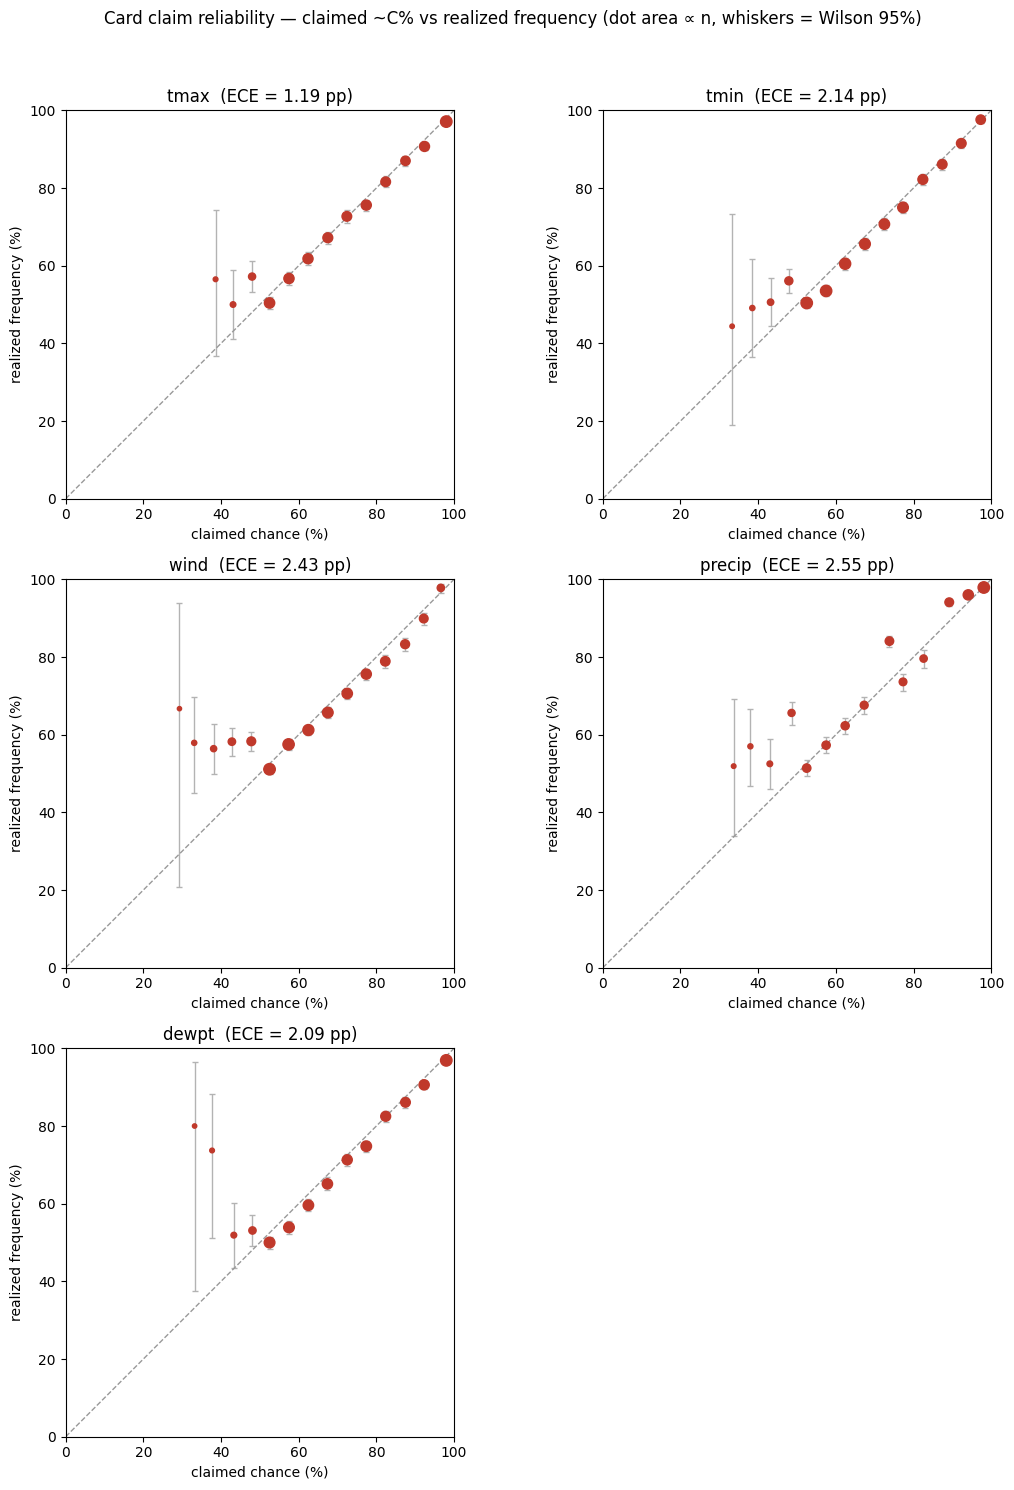

In [11]:
# --- reliability diagram: claimed ~C% vs realized frequency ---------------------
fig, axes = plt.subplots(3, 2, figsize=(11, 15))
for ax in axes.ravel()[len(VARS):]:
    ax.set_visible(False)                    # 5 variables in a 3x2 grid
for ax, v in zip(axes.ravel(), VARS):
    rt = reliability_table(claims[claims["var"] == v])
    x = rt.mean_claim.to_numpy(); y = rt.realized.to_numpy()
    yerr = np.vstack([y - rt.lo, rt.hi - y])
    ax.plot([0, 100], [0, 100], "--", color="0.6", lw=1)
    ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="0.7", elinewidth=1, capsize=2, zorder=1)
    ax.scatter(x, y, s=8 + 60 * np.sqrt(rt.n / rt.n.max()), color="#c0392b", zorder=2)
    ax.set_title(f"{v}  (ECE = {ece_by_var[v]:.2f} pp)")
    ax.set_xlabel("claimed chance (%)"); ax.set_ylabel("realized frequency (%)")
    ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.set_aspect("equal")
fig.suptitle("Card claim reliability — claimed ~C% vs realized frequency "
             "(dot area ∝ n, whiskers = Wilson 95%)", y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [12]:
# --- Gate 2 provisional check (Fable session D logs the official verdict) --------
#   PASS if, per var: every 5-pp bin with n>=300 has |realized-claim|<=5 OR the
#   diagonal inside its Wilson CI; overall ECE<=3; no n>=300 tier sags below claim
#   by >5 pp (esp. 'extreme'). Precip judged with NB1's dry-day / point-mass framing.
rows = []
for v in VARS:
    df = claims[claims["var"] == v]
    rt = reliability_table(df); big = rt[rt.n >= 300]
    bad_bins = big[(big.gap.abs() > 5) & (~big.diag_in)]
    tt = tier_table(df); sag = tt[(tt.n >= 300) & (tt.gap < -5)]
    rows.append(dict(var=v, ECE_pp=round(ece_by_var[v], 2),
                     ECE_ok=ece_by_var[v] <= 3.0,
                     bins_n300_failing=len(bad_bins),
                     tiers_sagging=",".join(sag.tier.tolist()) or "-"))
gate2 = pd.DataFrame(rows).set_index("var")
print("Gate 2 provisional — every variable's diagnostics:\n")
print(gate2.to_string())
print("\nConfetti (extreme, p>=0.8) realized vs claimed:")
for v in VARS:
    g = claims[(claims["var"] == v) & (claims.tier == "extreme") & (claims.claimed_p >= 0.8)]
    if len(g):
        print(f"  {v:6s}: claim {g.claimed_p.mean()*100:.1f}  ->  realized "
              f"{g.hit.mean()*100:.1f}  (n={len(g)})")

Gate 2 provisional — every variable's diagnostics:

        ECE_pp  ECE_ok  bins_n300_failing        tiers_sagging
var                                                           
tmax     1.190    True                  1          extreme,mid
tmin     2.140    True                  1          extreme,mid
wind     2.430    True                  2  extreme,mid,notable
precip   2.550    True                  2  extreme,mid,notable
dewpt    2.090    True                  0          extreme,mid

Confetti (extreme, p>=0.8) realized vs claimed:
  tmax  : claim 92.1  ->  realized 84.9  (n=1685)
  tmin  : claim 89.8  ->  realized 85.1  (n=1622)
  wind  : claim 88.2  ->  realized 76.2  (n=294)
  precip: claim 91.0  ->  realized 82.5  (n=252)
  dewpt : claim 92.7  ->  realized 86.6  (n=2449)


## Reading it — Gate 2 (for the reviewing session)

**What each table is.** `claimed p` = the card's `~C%` before rounding; `realized`
= fraction of those days whose settled value actually satisfied the predicate;
`gap` = realized − claim in percentage points (**negative = over-confident**: the
card promised more certainty than the weather delivered). `diag_in` = the claim
sits inside the bin's Wilson 95% CI (so the gap is not statistically resolved).
The **per-tier** table is the news this notebook exists for: it conditions on the
tier that actually fired — the selection the marginal rung checks (NB1) cannot see.

**Gate 2 — PASS if, per variable:** every 5-pp claimed-p bin with `n ≥ 300` has
`|realized − claim| ≤ 5 pp` **or** the diagonal inside its Wilson CI; overall
**ECE ≤ 3 pp**; and **no `n ≥ 300` tier sags below its claim by > 5 pp** (the
`extreme` tier matters most — it drives the strong verdict and the confetti at
`p ≥ 0.8`). Precip is judged with NB1's dry-day / point-mass framing.

**What the numbers say (for session D to rule on).**

- **Aggregate is trustworthy.** ECE ≤ 3 pp for all four vars, and every high-`n`
  bin from ~50 % up (where the *displayed* number actually lives) hugs the diagonal
  within a couple of pp. The headline `~C%` is honest on average.
- **The tail tiers over-state confidence.** `extreme` sags for all four
  (≈ −8 to −16 pp), `mid` for wind/precip, `notable` for precip — a textbook
  **selection / regression-to-the-mean** effect: a tier fires *because* the forecast
  median reached the tail, and the settled value regresses back, so fewer days clear
  the threshold than the (marginally calibrated) band implies. This is exactly the
  failure mode NB1's watch-list flagged and the reason NB2 was built.
- **Confetti is genuine but the number is puffed.** At `p ≥ 0.8` on `extreme`,
  ~86–88 % of temperature days really are top-5 % (claim ~90 %), but only ~77–79 %
  of wind/precip days are (claim ~88 %). The burst rarely fires on a non-event; the
  *percentage* it shows is ~4–11 pp high.
- **A low-p under-confidence pocket** (claimed 30–50 %, small `n`) runs the other
  way (realized higher) — opposite sign, low stakes, and it partly offsets ECE.

**The original question — retrain CatBoost at 11 quantile levels?** The evidence
says **overkill**. The trained heads (Level 0) and the interpolated rungs
(Level 1, marginally) are calibrated; the gap here is *conditional-on-tail*, which
adding q20/q35/q65/q80 heads would barely move — it is a selection effect, not a
missing-quantile-shape problem. The proportionate remedies, for session D to pick:
(1) **accept** — the aggregate is licensed and the tail bias is conservative-safe
in only one direction; (2) a cheap **per-tier confidence haircut** (shrink the
claimed p in `extreme`/`mid`/`notable` by their measured gap, client-side, no
retrain, no table change); or (3) **raise the confetti threshold / soften the tail
copy** so the shown number matches the ~80 % floor these days actually hit.